In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd
import numpy as np
import string
import re
import nltk

from tqdm import trange
from nltk import tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

file_path = '../datasets/with_stop_word/amazon_user_reviews_textANDfeature_with_sw_final.parquet'

df = pd.read_parquet(file_path)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18400 entries, 0 to 18399
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   original_text      18400 non-null  object 
 1   sentiment          18400 non-null  int64  
 2   exclamation_count  18400 non-null  int64  
 3   question_count     18400 non-null  int64  
 4   word_count         18400 non-null  int64  
 5   char_count         18400 non-null  int64  
 6   all_caps_words     18400 non-null  int64  
 7   uppercase_ratio    18400 non-null  float64
 8   total_punctuation  18400 non-null  int64  
 9   avg_word_length    18400 non-null  float64
 10  hour               18400 non-null  int32  
 11  month              18400 non-null  int32  
 12  season             18400 non-null  int64  
 13  vader_neg          18400 non-null  float64
 14  vader_neu          18400 non-null  float64
 15  vader_pos          18400 non-null  float64
 16  vader_compound     184

In [35]:
to_remove = ["original_text", "sentiment"]
features = df.columns.difference(to_remove, sort=False)
print(features)

Index(['exclamation_count', 'question_count', 'word_count', 'char_count',
       'all_caps_words', 'uppercase_ratio', 'total_punctuation',
       'avg_word_length', 'hour', 'month', 'season', 'vader_neg', 'vader_neu',
       'vader_pos', 'vader_compound', 'NN_count', 'JJ_count', 'VB_count',
       'RB_count', 'DT_count', 'PRP_count', 'PUNCT_count'],
      dtype='object')


In [18]:
# 5. Check for multicollinearity
print("\ MULTICOLLINEARITY CHECK, threshold = 0.8")
print("-" * 80)
high_corr_pairs = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr_val = df[features[i]].corr(df[features[j]])
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((features[i], features[j], corr_val))

if high_corr_pairs:
    print("Highly correlated feature pairs (>0.8):")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  - {feat1} <-> {feat2}: {corr_val:.3f}")
    print("\nRecommendation: Keep only one feature from each highly correlated pair")
else:
    print("No highly correlated features found (threshold: 0.8)")


\ MULTICOLLINEARITY CHECK, threshold = 0.8
--------------------------------------------------------------------------------
Highly correlated feature pairs (>0.8):
  - word_count <-> char_count: 0.997
  - word_count <-> total_punctuation: 0.935
  - word_count <-> NN_count: 0.935
  - word_count <-> JJ_count: 0.950
  - word_count <-> VB_count: 0.980
  - word_count <-> RB_count: 0.906
  - word_count <-> DT_count: 0.970
  - word_count <-> PRP_count: 0.876
  - word_count <-> PUNCT_count: 0.943
  - char_count <-> total_punctuation: 0.938
  - char_count <-> NN_count: 0.947
  - char_count <-> JJ_count: 0.954
  - char_count <-> VB_count: 0.970
  - char_count <-> RB_count: 0.892
  - char_count <-> DT_count: 0.965
  - char_count <-> PRP_count: 0.850
  - char_count <-> PUNCT_count: 0.946
  - total_punctuation <-> NN_count: 0.880
  - total_punctuation <-> JJ_count: 0.906
  - total_punctuation <-> VB_count: 0.923
  - total_punctuation <-> RB_count: 0.857
  - total_punctuation <-> DT_count: 0.894
  -

<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
/var/folders/28/4py847v94qvbv5v7yzm79jg80000gn/T/ipykernel_9392/694446274.py:2: SyntaxWarning: invalid escape sequence '\ '
  print("\ MULTICOLLINEARITY CHECK, threshold = 0.8")


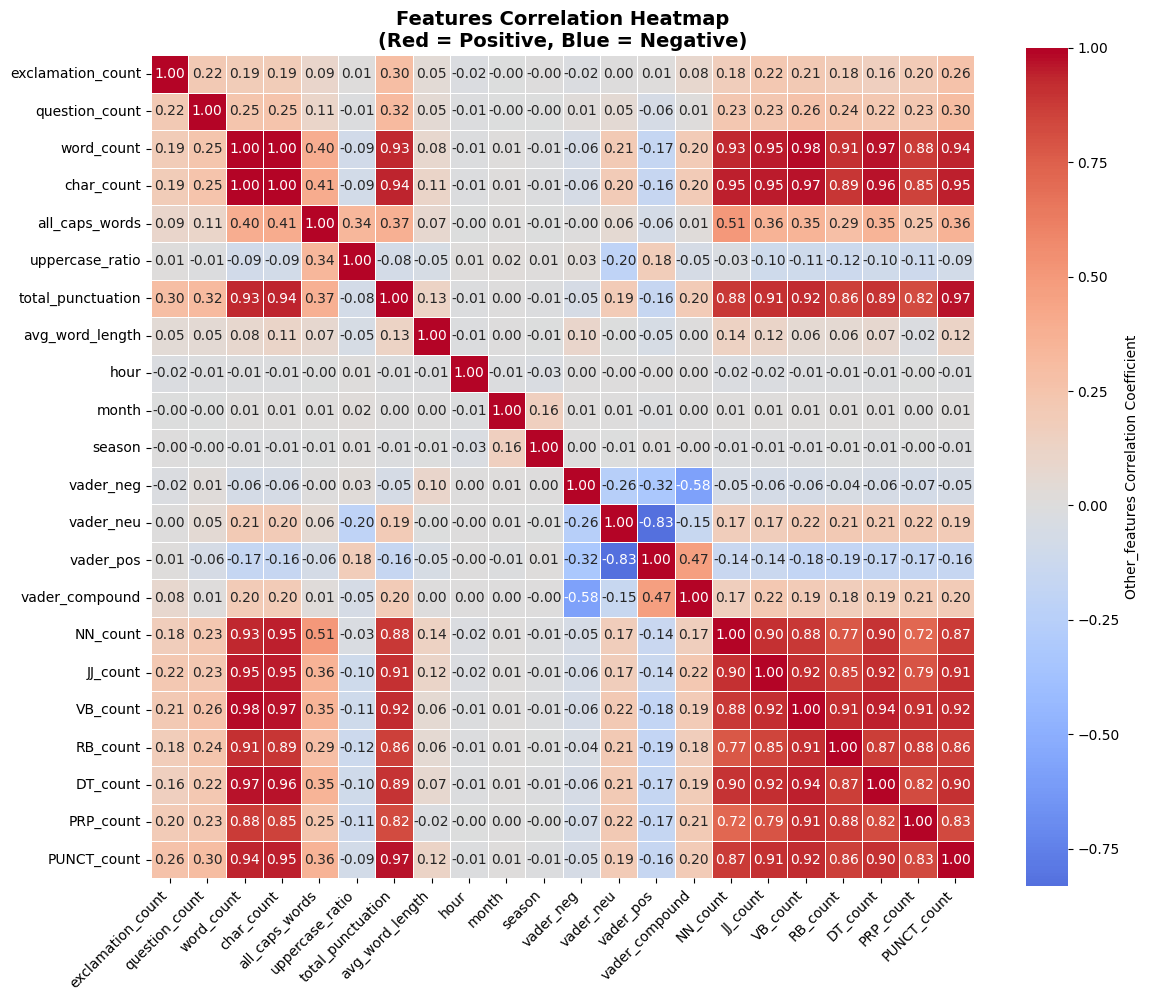

In [14]:
#6.  CORRELATION MATRIX BETWEEN OTHER_FEATURES

corr_matrix = df[features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='coolwarm',      # Color scheme
            center=0,             # Center colormap at 0
            square=True,          # Make cells square
            linewidths=0.5,       # Grid lines
            cbar_kws={'label': 'Other_features Correlation Coefficient'})

plt.title('Features Correlation Heatmap\n(Red = Positive, Blue = Negative)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
# Save the file
# plt.savefig("multicolinarity_heatmap_other_features.png", dpi=300, bbox_inches='tight')
plt.show()

# “features": "text_features" + "other_features"

In [20]:
# 1. CORRELATION WITH sentiment

print("ALl featrues: CORRELATION WITH sentiment")

# Calculate correlation of each feature with sentiment
target_cols = features.tolist() + ["sentiment"]
df_subset = df[target_cols]
correlations = df_subset.corr()['sentiment'].sort_values(ascending=False)
print("\n", correlations)

ALl featrues: CORRELATION WITH sentiment

 sentiment            1.000000
vader_neg            0.337752
vader_neu            0.254772
question_count       0.064425
all_caps_words       0.044342
RB_count             0.036400
uppercase_ratio      0.023703
VB_count             0.004711
month                0.001984
hour                -0.002227
DT_count            -0.005710
total_punctuation   -0.006350
season              -0.008761
word_count          -0.010024
char_count          -0.010560
PUNCT_count         -0.012939
PRP_count           -0.013287
NN_count            -0.017279
avg_word_length     -0.019400
JJ_count            -0.035680
exclamation_count   -0.040582
vader_pos           -0.444256
vader_compound      -0.488089
Name: sentiment, dtype: float64


In [16]:
# 2.2.  Check for multicollinearity - The Percentile Approach (Distribution-Based) - calculate new threshold

# Calculate the absolute correlation matrix
corr_matrix = df[features].corr().abs()

# Extract only the upper triangle (to avoid self-correlation and duplicates)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
all_corrs = upper_tri.stack().values

# Dynamically set threshold at the 95th percentile
dynamic_threshold = np.percentile(all_corrs, 95)
print(f"Suggested threshold based on data distribution: {dynamic_threshold:.3f}")


Suggested threshold based on data distribution: 0.940


In [17]:
# 2.2.  Check for multicollinearity - The Percentile Approach (Distribution-Based), threshold = 0.940
print("All MULTICOLLINEARITY CHECK, threshold = 0.940")
print("-" * 80)
high_corr_pairs = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr_val = df[features[i]].corr(df[features[j]])
        if abs(corr_val) > 0.940:
            high_corr_pairs.append((features[i], features[j], corr_val))

if high_corr_pairs:
    print("Highly correlated feature pairs (>0.940):")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  - {feat1} <-> {feat2}: {corr_val:.3f}")
    print("\nRecommendation: Keep only one feature from each highly correlated pair")
else:
    print("No highly correlated features found (threshold: 0.940)")


All MULTICOLLINEARITY CHECK, threshold = 0.940
--------------------------------------------------------------------------------
Highly correlated feature pairs (>0.940):
  - word_count <-> char_count: 0.997
  - word_count <-> JJ_count: 0.950
  - word_count <-> VB_count: 0.980
  - word_count <-> DT_count: 0.970
  - word_count <-> PUNCT_count: 0.943
  - char_count <-> NN_count: 0.947
  - char_count <-> JJ_count: 0.954
  - char_count <-> VB_count: 0.970
  - char_count <-> DT_count: 0.965
  - char_count <-> PUNCT_count: 0.946
  - total_punctuation <-> PUNCT_count: 0.969
  - VB_count <-> DT_count: 0.944

Recommendation: Keep only one feature from each highly correlated pair


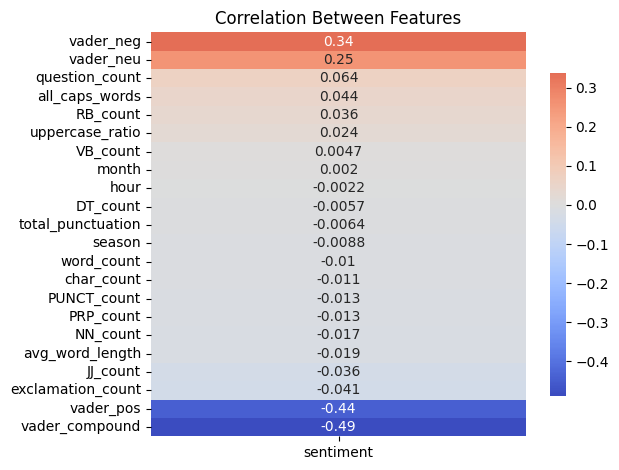

In [36]:
# 3. DESCENDING CORRELATION VISUALIZATION

target_cols = features.tolist() + ["sentiment"]
df_subset = df[target_cols]
corr_with_sentiment =  df_subset.corr()[["sentiment"]].drop("sentiment").sort_values("sentiment", ascending=False)

sns.heatmap(
    corr_with_sentiment,
    annot=True,
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Between Features")
plt.tight_layout()
# plt.savefig("correlation between target and (all) features_1.png")
plt.show()


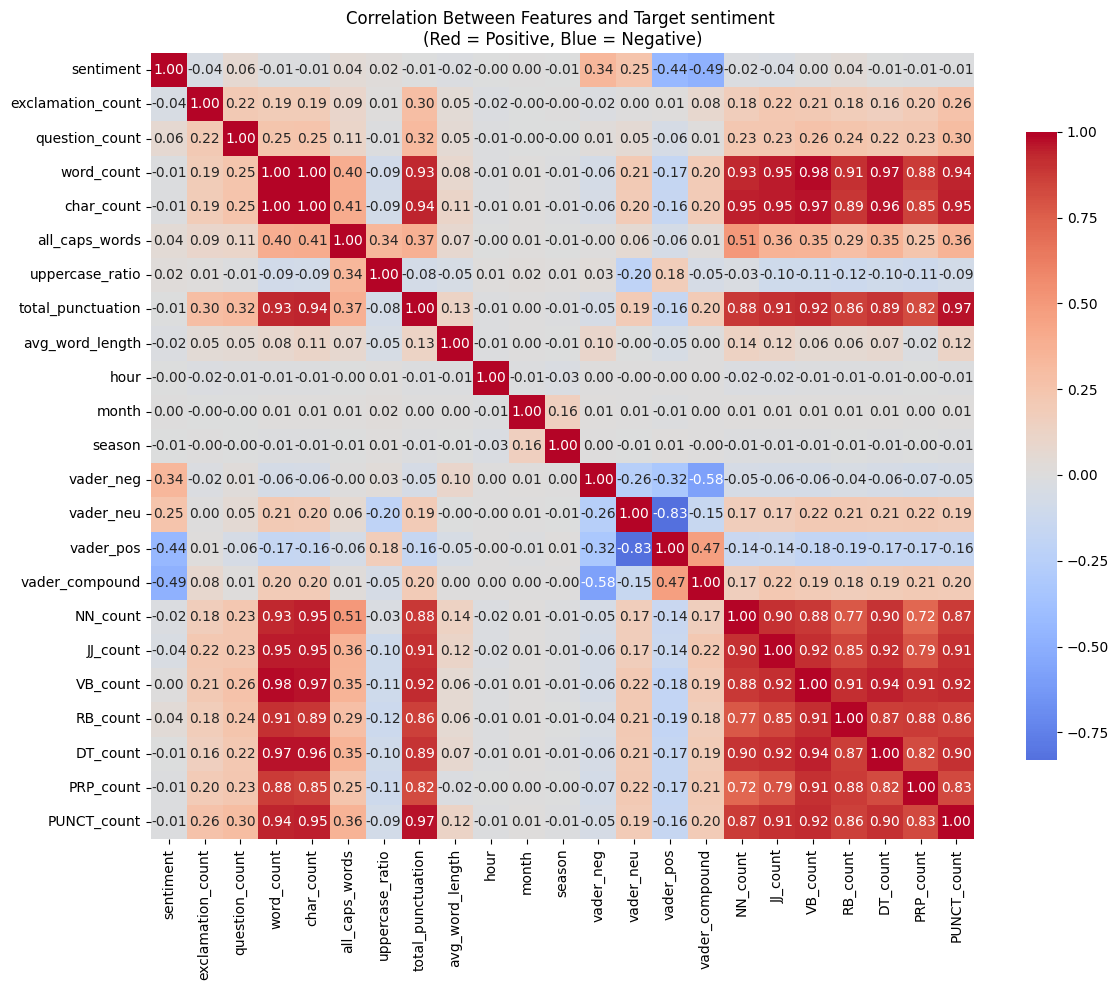

In [27]:
# 4. CORRELATION WITH TARGET FULL VISUALIZATION
target_cols = ["sentiment"] + features.tolist() 
df_subset = df[target_cols]
plt.figure(figsize=(12, 10))
corr_with_sentiment = df_subset.corr()

sns.heatmap(
    corr_with_sentiment,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Between Features and Target sentiment \n(Red = Positive, Blue = Negative)")
plt.tight_layout()
# plt.savefig("correlation between target and (all) features_2.png")
plt.show()


# Training Dateset Processing - Drop Datset

In [32]:
# based on multicolinearlity
to_remove = ["original_text", "sentiment","char_count", "word_count", "total_punctuation", "DT_count"]
features_engineered = df.columns.difference(to_remove, sort=False)
print(features_engineered)

Index(['exclamation_count', 'question_count', 'all_caps_words',
       'uppercase_ratio', 'avg_word_length', 'hour', 'month', 'season',
       'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'NN_count',
       'JJ_count', 'VB_count', 'RB_count', 'PRP_count', 'PUNCT_count'],
      dtype='object')


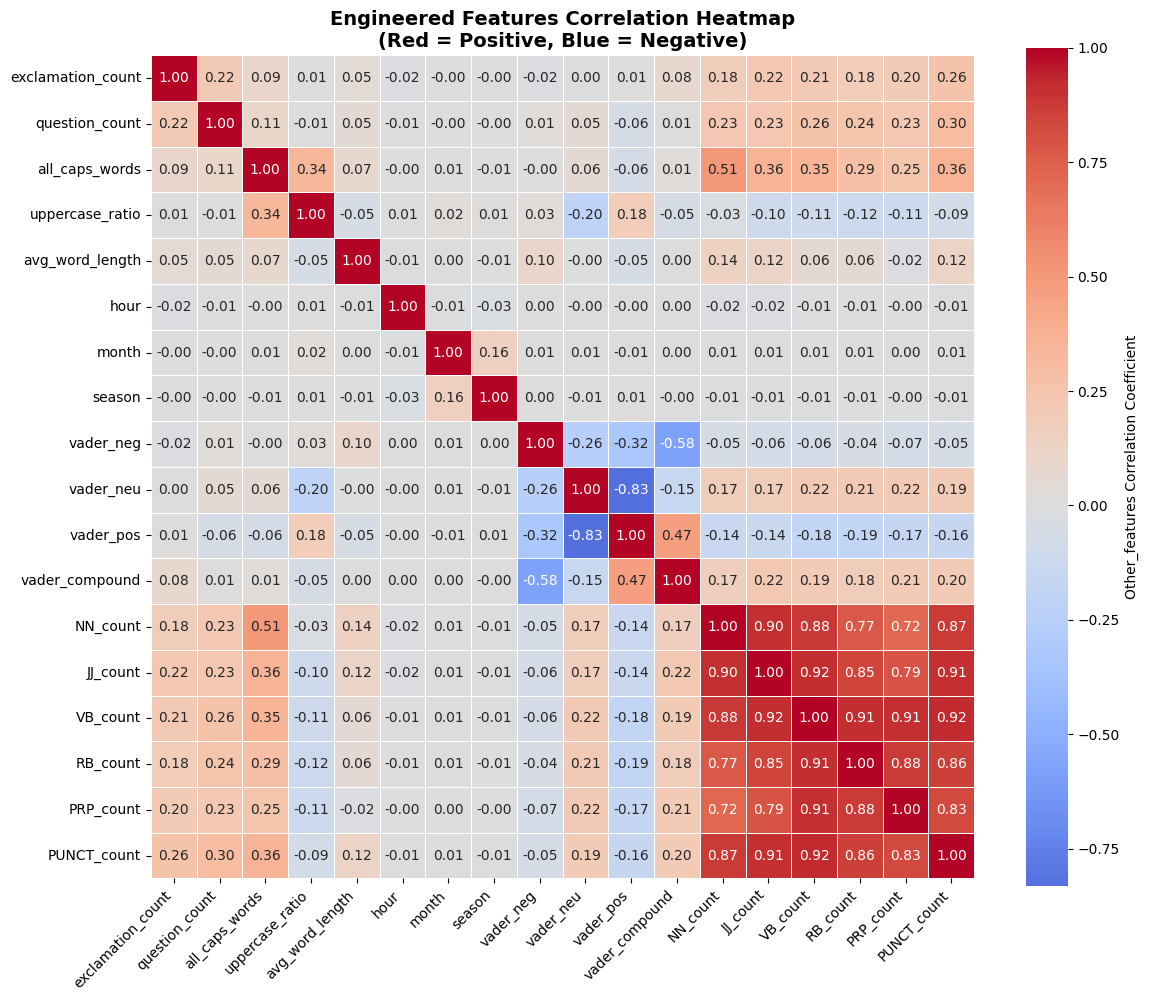

In [33]:
#6.  CORRELATION MATRIX BETWEEN OTHER_FEATURES

corr_matrix = df[features_engineered].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='coolwarm',      # Color scheme
            center=0,             # Center colormap at 0
            square=True,          # Make cells square
            linewidths=0.5,       # Grid lines
            cbar_kws={'label': 'Other_features Correlation Coefficient'})

plt.title('Engineered Features Correlation Heatmap\n(Red = Positive, Blue = Negative)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
# Save the file
# plt.savefig("multicolinarity_heatmap_other_features.png", dpi=300, bbox_inches='tight')
plt.show()

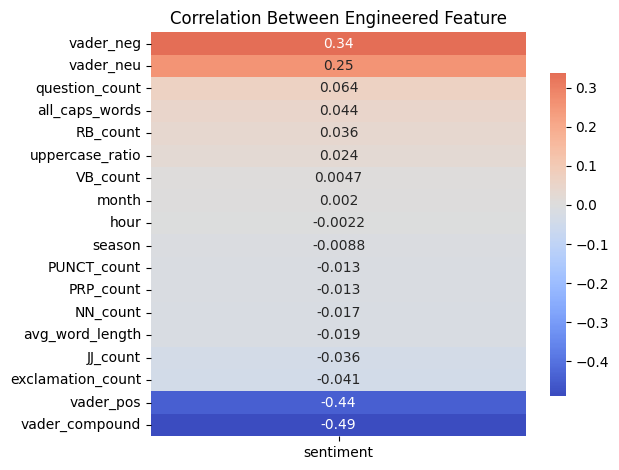

In [37]:
# 3. DESCENDING CORRELATION VISUALIZATION

target_cols = features_engineered.tolist() + ["sentiment"]
df_subset_engineered = df[target_cols]
corr_with_sentiment =  df_subset_engineered.corr()[["sentiment"]].drop("sentiment").sort_values("sentiment", ascending=False)

sns.heatmap(
    corr_with_sentiment,
    annot=True,
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Between Engineered Feature")
plt.tight_layout()
# plt.savefig("correlation between target and (all) features_1.png")
plt.show()


In [36]:
feature_text_col = ["original_text"] + simplified_col
feature_text_df = df[feature_text_col]
feature_text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18400 entries, 0 to 18399
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   original_text          18400 non-null  object 
 1   sentiment              18400 non-null  int64  
 2   exclamation_count      18400 non-null  int64  
 3   question_count         18400 non-null  int64  
 4   word_count             18400 non-null  int64  
 5   char_count             18400 non-null  int64  
 6   all_caps_words         18400 non-null  int64  
 7   uppercase_ratio        18400 non-null  float64
 8   total_punctuation      18400 non-null  int64  
 9   avg_word_length        18400 non-null  float64
 10  helpful_vote           18400 non-null  int64  
 11  int_verified_purchase  18400 non-null  int64  
 12  hour                   18400 non-null  int32  
 13  month                  18400 non-null  int32  
 14  season                 18400 non-null  int64  
dtypes:

In [ ]:
# feature_text_df.to_parquet('amazon_user_reviews_textANDfeature_sentiment_with_sw.parquet', index=False)